In [658]:
import pypsa
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [659]:
# Netzwerk & Snapshots

In [660]:
snapshots = pd.date_range("2019-01-01", periods=12, freq="MS")
n = pypsa.Network()
n.set_snapshots(snapshots)
print(snapshots)

DatetimeIndex(['2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01',
               '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01',
               '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01'],
              dtype='datetime64[ns]', freq='MS')


In [661]:
# Dummy-Netz für eine valide Zielfunktion

In [662]:
n.add("Carrier", "dummy")
n.add("Bus", "bus0", carrier="dummy")
n.add("Generator", "dummy_gen", bus="bus0",
      p_nom=1.0, p_min_pu=0.0, p_max_pu=0.0, marginal_cost=1e-6)

Index(['dummy_gen'], dtype='object')

In [663]:
# Daten laden

In [664]:
df_crops_parameter = pd.read_excel("../Input/Finale_Pflanzendaten_Mappe.xlsx", sheet_name="crops_parameter").set_index("crop")
df_crops_yield     = pd.read_excel("../Input/Finale_Pflanzendaten_Mappe.xlsx", sheet_name="crops_yield").set_index("snapshot")
df_person_demand   = pd.read_excel("../Input/Finale_Pflanzendaten_Mappe.xlsx", sheet_name="person_demand").set_index("person")
print(df_crops_parameter.head())
print(df_crops_yield.head())
print(df_person_demand.head())

          energy_kwh_per_m2_month  light_kwh_per_m2_month  y_cycle_kg_m2  \
crop                                                                       
Tomate                     225.00                   144.0      53.951923   
Paprika                     58.00                    37.0      18.500000   
Gurke                      118.75                    75.0      40.675714   
Salat                       17.60                    11.0       4.713333   
Zucchini                    15.00                     9.0       6.195385   

          T_days  W_max  kcal_per_kg  prot_g_per_kg  carb_g_per_kg  \
crop                                                                 
Tomate        90      7          190            7.0           35.0   
Paprika      120      9          430           13.0           64.0   
Gurke        120      5          140            6.0           18.0   
Salat         30      6          140           12.0           11.0   
Zucchini      90      7          190           

In [665]:
# Daten weiter verarbeiten

In [666]:
crops = list(df_crops_yield.columns)
yield_per_area = xr.DataArray(
    df_crops_yield.values,
    coords={"snapshot": snapshots, "crop": df_crops_yield.columns},
    dims=("snapshot", "crop")
)
print(crops)
print(yield_per_area)

['Tomate', 'Paprika', 'Gurke', 'Salat', 'Zucchini', 'Kohlrabi', 'Spinat', 'Kartoffel', 'Erdbeere', 'Sojabohne', 'Linsen', 'Kichererbsen', 'Bohnen', 'Mangold', 'Radisschen', 'Rote Bete', 'Suesskartoffel']
<xarray.DataArray (snapshot: 12, crop: 17)> Size: 2kB
array([[ 0. ,  0. ,  0. ,  4.7,  0. ,  0. ,  2.1,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  5. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  4.7,  0. ,  0. ,  2.1,  0. ,  0. ,  0. ,  0. ,
         0. ,  2.9,  8.3,  5. ,  7.6,  0. ],
       [54. ,  0. ,  0. ,  4.7,  6.2,  4.8,  2.1,  6.5,  5.8,  1. ,  0.3,
         0.4,  0. ,  0. ,  5. ,  0. ,  0. ],
       [ 0. , 18.5, 40. ,  4.7,  0. ,  0. ,  2.1,  0. ,  0. ,  0. ,  0. ,
         0. ,  2.9,  8.3,  5. ,  7.6, 10. ],
       [ 0. ,  0. ,  0. ,  4.7,  0. ,  0. ,  2.1,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  5. ,  0. ,  0. ],
       [54. ,  0. ,  0. ,  4.7,  6.2,  4.8,  2.1,  6.5,  5.8,  1. ,  0.3,
         0.4,  2.9,  8.3,  5. ,  7.6,  0. ],
       [ 0. ,  0. ,  0. ,  4

In [667]:
# Wachstumsdauer in Monaten (gerundet) definieren:

In [668]:
growth_months = (
    (df_crops_parameter.loc[crops, "T_days"] / 30)
    .round()
    .clip(lower=1)
    .astype(int)
    .to_dict()
)
print(growth_months)

{'Tomate': 3, 'Paprika': 4, 'Gurke': 4, 'Salat': 1, 'Zucchini': 3, 'Kohlrabi': 3, 'Spinat': 1, 'Kartoffel': 3, 'Erdbeere': 3, 'Sojabohne': 3, 'Linsen': 3, 'Kichererbsen': 3, 'Bohnen': 2, 'Mangold': 2, 'Radisschen': 1, 'Rote Bete': 2, 'Suesskartoffel': 4}


In [669]:
# Max vorgegebene Fläche

In [670]:
Amax_total = 85  # m²

In [671]:
# Personen Anzahl definieren:

In [672]:
person = 1
row = df_person_demand.loc[person]
print(df_person_demand.loc[person])

kcal       2250
prot_g       55
carb_g      260
sugar_g      25
fiber_g      30
fat_g        75
Name: 1, dtype: int64


In [673]:
# Lager anfangsbestand

In [674]:
S_init_factor = 1.0

In [675]:
# Linopy-Modell:

In [676]:
m = n.optimize.create_model()

In [677]:
# Entscheidungsvariabeln

In [678]:
# Startfläche je Monat & Kultur: "wie viel m² starte ich in diesem Monat?"
x_start = m.add_variables(lower=0.0, name="x_start", coords=[("snapshot", n.snapshots), ("crop", crops)])

#  Aktive Fläche je Monat & Kultur
area_active = m.add_variables(lower=0.0, name="area_active", coords=[("snapshot", n.snapshots), ("crop", crops)])

# Erntemenge je Monat & Kultur (kg)
harvest = m.add_variables(lower=0.0, name="harvest", coords=[("snapshot", n.snapshots), ("crop", crops)])

# Anzahl an starts je Kultur:
z_start = m.add_variables(binary=True, name="z_start", coords=[("snapshot", n.snapshots), ("crop", crops)])

In [679]:
snap_list = list(n.snapshots.values)
T = len(snap_list)

In [680]:
#  Nebenbedingungen: Constraints:

In [681]:
m.add_constraints(area_active.sum("crop") <= Amax_total, name="total_area_cap")

Constraint `total_area_cap` [snapshot: 12]:
-------------------------------------------
[2019-01-01 00:00:00]: +1 area_active[2019-01-01 00:00:00, Tomate] + 1 area_active[2019-01-01 00:00:00, Paprika] + 1 area_active[2019-01-01 00:00:00, Gurke] ... +1 area_active[2019-01-01 00:00:00, Radisschen] + 1 area_active[2019-01-01 00:00:00, Rote Bete] + 1 area_active[2019-01-01 00:00:00, Suesskartoffel] ≤ 85.0
[2019-02-01 00:00:00]: +1 area_active[2019-02-01 00:00:00, Tomate] + 1 area_active[2019-02-01 00:00:00, Paprika] + 1 area_active[2019-02-01 00:00:00, Gurke] ... +1 area_active[2019-02-01 00:00:00, Radisschen] + 1 area_active[2019-02-01 00:00:00, Rote Bete] + 1 area_active[2019-02-01 00:00:00, Suesskartoffel] ≤ 85.0
[2019-03-01 00:00:00]: +1 area_active[2019-03-01 00:00:00, Tomate] + 1 area_active[2019-03-01 00:00:00, Paprika] + 1 area_active[2019-03-01 00:00:00, Gurke] ... +1 area_active[2019-03-01 00:00:00, Radisschen] + 1 area_active[2019-03-01 00:00:00, Rote Bete] + 1 area_active[2019-

In [682]:
# area_active-Definition:
# Für jede Kultur und jeden Monat setzt die Schleife area_active[h,c] gleich der Summe aller Startflächen x_start[t,c] der letzten L Monate

In [683]:
for c in crops:
    L = int(growth_months[c])
    for h in range(T):
        terms = []
        for k in range(L):
            t = h - k              # -> nichts vor Jahresbeginn
            if t < 0:
                continue
            terms.append(x_start.sel(snapshot=snap_list[t], crop=c))
        rhs = sum(terms) if terms else 0
        m.add_constraints(
            area_active.sel(snapshot=snap_list[h], crop=c) == rhs,
            name=f"def_area_active_nowrap_{c}_{h}"
        )

In [684]:
# Ernte definition:
# Für jede Kultur und jeden Monat berechnet die Schleife die Ernte harvest[h,c] als Summe der (ab L-1 Monaten nach Start) wirksamen Startflächen x_start[t,c] gewichtet mit dem Ertragsmuster y[d].

In [685]:
for c in crops:
    L = int(growth_months[c])
    y = yield_per_area.sel(crop=c).to_pandas().values  # y[d] = Ertrag d Monate nach Start
    for h in range(T):
        expr = 0
        for t in range(T):
            d = h - t
            if d < L - 1:   # in den ersten (L-1) Monaten nach Start: kein Ertrag
                continue
            expr += float(y[d]) * x_start.sel(snapshot=snap_list[t], crop=c)
        m.add_constraints(
            harvest.sel(snapshot=snap_list[h], crop=c) == expr,
            name=f"def_harvest_nowrap_{c}_{h}"
        )

In [686]:
# max. Anzahl Starts:
# Start-Link & Limit: x_start ≤ 1e3 ·z_start erlaubt Startfläche nur, wenn im selben Monat ein Start-Binär z_start aktiv ist,
# und ∑_h z_start[h,c] ≤ N_starts[c] begrenzt die Anzahl Zyklen je Kultur pro Jahr.

In [687]:
m.add_constraints(x_start <= 1e3 * z_start, name="link_start_area")

N_starts = {c: 12 for c in crops}  # -> max. 1 Zyklus pro Kultur und Jahr
for c in crops:
    m.add_constraints(
        z_start.sel(crop=c).sum("snapshot") <= N_starts[c],
        name=f"max_starts_{c}"
    )

In [688]:
# erzwingt: In jedem Fenster der letzten L Monate darf für eine Kultur höchstens ein z_start = 1 sein ⇒ zwei Starts derselben Kultur müssen mindestens L Monate auseinanderliegen, also keine überlappenden Wachstumsphasen.

In [689]:
for c in crops:
    L = int(growth_months[c])
    for h in range(T):
        terms = []
        for k in range(L):
            t = h - k
            if t < 0:        # nichts vor Jahresbeginn
                continue
            terms.append(z_start.sel(snapshot=snap_list[t], crop=c))
        if terms:
            m.add_constraints(sum(terms) <= 1, name=f"no_overlap_nowrap_{c}_{h}")


In [690]:
# 9) Nährstoff-Outputs je kg Ernte

In [691]:
kcal_per_kg  = xr.DataArray(df_crops_parameter["kcal_per_kg"],      dims=["crop"], coords={"crop": df_crops_parameter.index})
prot_per_kg  = xr.DataArray(df_crops_parameter["prot_g_per_kg"],    dims=["crop"], coords={"crop": df_crops_parameter.index})
carb_per_kg  = xr.DataArray(df_crops_parameter["carb_g_per_kg"],    dims=["crop"], coords={"crop": df_crops_parameter.index})
sugar_per_kg = xr.DataArray(df_crops_parameter["sugar_g_per_kg"],   dims=["crop"], coords={"crop": df_crops_parameter.index})
fiber_per_kg = xr.DataArray(df_crops_parameter["fiber_g_per_kg"],   dims=["crop"], coords={"crop": df_crops_parameter.index})
fat_per_kg   = xr.DataArray(df_crops_parameter["fat_g_per_kg"],     dims=["crop"], coords={"crop": df_crops_parameter.index})

prod_kcal_expr  = (harvest * kcal_per_kg ).sum("crop")
prod_prot_expr  = (harvest * prot_per_kg ).sum("crop")
prod_carb_expr  = (harvest * carb_per_kg ).sum("crop")
prod_sugar_expr = (harvest * sugar_per_kg).sum("crop")
prod_fiber_expr = (harvest * fiber_per_kg).sum("crop")
prod_fat_expr   = (harvest * fat_per_kg)  .sum("crop")

In [692]:
# Lagerdynamik

In [693]:
def add_stock(m, name, prod_expr, demand, snapshots,
              S_init_factor=1.0, loss=0.0, allow_import=True):
    """
    Verderbliches Lager:
    t=0:  stock0 - prod0 + demand0 - imp0 = (1-loss)*S_init
    t>0:  stock_t - (1-loss)*stock_{t-1} - prod_t + demand_t - imp_t = 0
    """
    stock = m.add_variables(lower=0.0, name=name, coords=[("snapshot", snapshots)])

    imp = None
    if allow_import:
        base = name.replace("stock_", "")
        imp = m.add_variables(lower=0.0, name=f"imp_{base}", coords=[("snapshot", snapshots)])

    S_init = float(S_init_factor * demand.isel(snapshot=0))

    # t = 0  -> alles Variable links, reine Konstante rechts
    expr0 = stock.isel(snapshot=0) - prod_expr.isel(snapshot=0) + demand.isel(snapshot=0)
    if allow_import:
        expr0 = expr0 - imp.isel(snapshot=0)
    m.add_constraints(expr0 == (1.0 - loss) * S_init, name=f"{name}_balance_t0")

    # t = 1..T-1
    expr_dyn = (stock.isel(snapshot=slice(1,None))
                - (1.0 - loss) * stock.isel(snapshot=slice(0,-1))
                - prod_expr.isel(snapshot=slice(1,None))
                + demand.isel(snapshot=slice(1,None)))
    if allow_import:
        expr_dyn = expr_dyn - imp.isel(snapshot=slice(1,None))
    m.add_constraints(expr_dyn == 0, name=f"{name}_balance_dyn")

    return stock



In [694]:
# demand auslesen:

In [695]:
days_per_month = 30
demand_kcal  = xr.DataArray([row["kcal"]    * days_per_month]*len(n.snapshots), coords={"snapshot": n.snapshots}, dims=["snapshot"])
demand_prot  = xr.DataArray([row["prot_g"]  * days_per_month]*len(n.snapshots), coords={"snapshot": n.snapshots}, dims=["snapshot"])
demand_carb  = xr.DataArray([row["carb_g"]  * days_per_month]*len(n.snapshots), coords={"snapshot": n.snapshots}, dims=["snapshot"])
demand_sugar = xr.DataArray([row["sugar_g"] * days_per_month]*len(n.snapshots), coords={"snapshot": n.snapshots}, dims=["snapshot"])
demand_fiber = xr.DataArray([row["fiber_g"] * days_per_month]*len(n.snapshots), coords={"snapshot": n.snapshots}, dims=["snapshot"])
demand_fat   = xr.DataArray([row["fat_g"]   * days_per_month]*len(n.snapshots), coords={"snapshot": n.snapshots}, dims=["snapshot"])

print(demand_kcal.to_pandas().head())
print(demand_prot.to_pandas().head())
print(demand_carb.to_pandas().head())
print(demand_sugar.to_pandas().head())
print(demand_fiber.to_pandas().head())
print(demand_fat.to_pandas().head())

snapshot
2019-01-01    67500
2019-02-01    67500
2019-03-01    67500
2019-04-01    67500
2019-05-01    67500
Freq: MS, dtype: int64
snapshot
2019-01-01    1650
2019-02-01    1650
2019-03-01    1650
2019-04-01    1650
2019-05-01    1650
Freq: MS, dtype: int64
snapshot
2019-01-01    7800
2019-02-01    7800
2019-03-01    7800
2019-04-01    7800
2019-05-01    7800
Freq: MS, dtype: int64
snapshot
2019-01-01    750
2019-02-01    750
2019-03-01    750
2019-04-01    750
2019-05-01    750
Freq: MS, dtype: int64
snapshot
2019-01-01    900
2019-02-01    900
2019-03-01    900
2019-04-01    900
2019-05-01    900
Freq: MS, dtype: int64
snapshot
2019-01-01    2250
2019-02-01    2250
2019-03-01    2250
2019-04-01    2250
2019-05-01    2250
Freq: MS, dtype: int64


In [696]:
#Lagerfunktion für jeden nährwert aufrufen:

In [697]:
LOSS = 0.5  # z.B. 50%/Monat
stock_kcal  = add_stock(m, "stock_kcal",  prod_kcal_expr,  demand_kcal,  n.snapshots, S_init_factor, loss=LOSS, allow_import=False)
stock_prot  = add_stock(m, "stock_prot",  prod_prot_expr,  demand_prot,  n.snapshots, S_init_factor, loss=LOSS, allow_import=False)
stock_carb  = add_stock(m, "stock_carb",  prod_carb_expr,  demand_carb,  n.snapshots, S_init_factor, loss=LOSS, allow_import=False)
stock_sugar = add_stock(m, "stock_sugar", prod_sugar_expr, demand_sugar, n.snapshots, S_init_factor, loss=LOSS, allow_import=False)
stock_fiber = add_stock(m, "stock_fiber", prod_fiber_expr, demand_fiber, n.snapshots, S_init_factor, loss=LOSS, allow_import=False)
stock_fat   = add_stock(m, "stock_fat",   prod_fat_expr,   demand_fat,   n.snapshots, S_init_factor, loss=LOSS, allow_import=False)


In [698]:
imports_total = 0
for base in ["kcal","prot","carb","sugar","fiber","fat"]:
    v = f"imp_{base}"
    if v in m.variables:  # nur falls erlaubt
        imports_total = imports_total + m.variables[v].sum()

IMP_PENALTY = 1e9  # sehr hoch, damit Anbau fast immer günstiger ist
energy_use = (area_active * energy_kwh_per_m2_month).sum(["snapshot","crop"])
m.add_objective(energy_use + IMP_PENALTY*imports_total, sense="min", overwrite=True)


In [699]:
#stock_kcal  = add_stock(m, "stock_kcal",  prod_kcal_expr,  demand_kcal,  n.snapshots, S_init_factor)
#stock_prot  = add_stock(m, "stock_prot",  prod_prot_expr,  demand_prot,  n.snapshots, S_init_factor)
#stock_carb  = add_stock(m, "stock_carb",  prod_carb_expr,  demand_carb,  n.snapshots, S_init_factor)
#stock_sugar = add_stock(m, "stock_sugar", prod_sugar_expr, demand_sugar, n.snapshots, S_init_factor)
#stock_fiber = add_stock(m, "stock_fiber", prod_fiber_expr, demand_fiber, n.snapshots, S_init_factor)
#stock_fat   = add_stock(m, "stock_fat",   prod_fat_expr,   demand_fat,   n.snapshots, S_init_factor)

In [700]:
# Zielfunktion: Energieaufwand minimieren

In [701]:
col = "energy_kwh_per_m2_month"
energy_kwh_per_m2_month = xr.DataArray(
    df_crops_parameter.loc[crops, col].astype(float).values,
    coords={"crop": crops}, dims=["crop"], name="energy_kwh_per_m2_month")

print(energy_kwh_per_m2_month)

energy_use = (area_active * energy_kwh_per_m2_month).sum(["snapshot", "crop"])
m.add_objective(energy_use, sense="min", overwrite=True)

print(energy_use)
print(area_active)

<xarray.DataArray 'energy_kwh_per_m2_month' (crop: 17)> Size: 136B
array([225.  ,  58.  , 118.75,  17.6 ,  15.  ,  16.75,   6.75,  24.4 ,
         8.5 ,   2.5 ,   7.  ,   0.6 ,   6.  ,  21.  ,   7.2 ,  24.75,
        25.  ])
Coordinates:
  * crop     (crop) <U14 952B 'Tomate' 'Paprika' ... 'Suesskartoffel'
LinearExpression
----------------
+225 area_active[2019-01-01 00:00:00, Tomate] + 58 area_active[2019-01-01 00:00:00, Paprika] + 118.8 area_active[2019-01-01 00:00:00, Gurke] ... +7.2 area_active[2019-12-01 00:00:00, Radisschen] + 24.75 area_active[2019-12-01 00:00:00, Rote Bete] + 25 area_active[2019-12-01 00:00:00, Suesskartoffel]
Variable (snapshot: 12, crop: 17)
---------------------------------
[2019-01-01 00:00:00, Tomate]: area_active[2019-01-01 00:00:00, Tomate] ∈ [0, inf]
[2019-01-01 00:00:00, Paprika]: area_active[2019-01-01 00:00:00, Paprika] ∈ [0, inf]
[2019-01-01 00:00:00, Gurke]: area_active[2019-01-01 00:00:00, Gurke] ∈ [0, inf]
[2019-01-01 00:00:00, Salat]: area_activ

In [702]:
# Lösen

In [703]:
n.optimize.solve_model(solver_name="gurobi")

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 1.45s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2694931


INFO:gurobipy:Set parameter LicenseID to value 2694931


...

Model is infeasible


INFO:gurobipy:Model is infeasible


Best objective -, best bound -, gap -


INFO:gurobipy:Best objective -, best bound -, gap -
INFO:linopy.solvers:Unable to save solution file. Raised error: Unable to retrieve attribute 'X'
Status: warning
Termination condition: infeasible
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: 3



('warning', 'infeasible')

In [704]:
# Ergebnisse

In [705]:
# =========================
# Ergebnisse (kompakt, ohne Duplikate)
# =========================
area_opt    = m.variables["area_active"].solution         # (snapshot, crop) in m²
harvest_sol = m.variables["harvest"].solution             # (snapshot, crop) in kg

# (A) Kennzahlen Fläche
df_area       = area_opt.to_pandas()
max_used_area = df_area.sum(axis=1).max()
print(f"\n[Key Metric] Maximal gleichzeitig genutzte Fläche: {max_used_area:.1f} m²")

built_from_area = (area_opt.sum("snapshot") > 1e-6).to_pandas().astype(int)  # 0/1 je Kultur
area_year       = area_opt.sum("snapshot").to_pandas()                        # m²·Monat

# (B) Energie über das Jahr je Kultur
energy_year_by_crop = (area_opt * energy_kwh_per_m2_month).sum("snapshot").to_pandas()
energy_intensity_a  = (energy_kwh_per_m2_month * 12).to_pandas()

# (C) Zusammenfassung bauen & ausgeben
df_summary = (
    pd.DataFrame({
        "gebaut": built_from_area,
        "Jahresfläche [m²·Monat]": area_year,
        "Energie-Intensität [kWh/(m²·a)]": energy_intensity_a.reindex(area_year.index),
        "Jahresenergie [kWh/a]": energy_year_by_crop
    })
    .query("gebaut == 1")
    .sort_values("Jahresenergie [kWh/a]", ascending=False)
    .round(1)
)
print("\n[Übersicht] Gebaute Kulturen (sortiert nach Jahresenergie):")
print(df_summary)

grown_crops = df_summary.index.tolist()
print("\nAngebaut werden:", ", ".join(grown_crops) if grown_crops else "keine")

def months_active(da):
    s = da.to_pandas() > 1e-6
    return ", ".join(s.index[s].strftime("%b"))

print("\nMonate je Kultur (falls gebaut):")
for crop in grown_crops:
    print(f"- {crop}: {months_active(area_opt.sel(crop=crop))}")

# (D) Nährstoffproduktion & Verfügbarkeit
prod_kcal_sol  = (harvest_sol * kcal_per_kg ).sum("crop")
prod_prot_sol  = (harvest_sol * prot_per_kg ).sum("crop")
prod_carb_sol  = (harvest_sol * carb_per_kg ).sum("crop")
prod_sugar_sol = (harvest_sol * sugar_per_kg).sum("crop")
prod_fiber_sol = (harvest_sol * fiber_per_kg).sum("crop")
prod_fat_sol   = (harvest_sol * fat_per_kg  ).sum("crop")

def available_this_month(stock_sol, prod_sol):
    stock_prev = stock_sol.shift(snapshot=1, fill_value=0)
    return stock_prev + prod_sol

# Falls du die Lager-Variablen angelegt hast, kannst du 'avail' so berechnen:
avail = {
    "kcal":  available_this_month(m.variables["stock_kcal"].solution,  prod_kcal_sol),
    "prot":  available_this_month(m.variables["stock_prot"].solution,  prod_prot_sol),
    "carb":  available_this_month(m.variables["stock_carb"].solution,  prod_carb_sol),
    "sugar": available_this_month(m.variables["stock_sugar"].solution, prod_sugar_sol),
    "fiber": available_this_month(m.variables["stock_fiber"].solution, prod_fiber_sol),
    "fat":   available_this_month(m.variables["stock_fat"].solution,   prod_fat_sol),
}


C:\Users\sarah\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning:

ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead

C:\Users\sarah\anaconda3\Lib\ast.py:587: DeprecationWarning:

Attribute s is deprecated and will be removed in Python 3.14; use value instead

C:\Users\sarah\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning:

ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead

C:\Users\sarah\anaconda3\Lib\ast.py:587: DeprecationWarning:

Attribute s is deprecated and will be removed in Python 3.14; use value instead



AttributeError: Underlying model not optimized.

In [590]:
# Plots – Anbauart und optimale Fläche pro Monat (Stacked Bar)

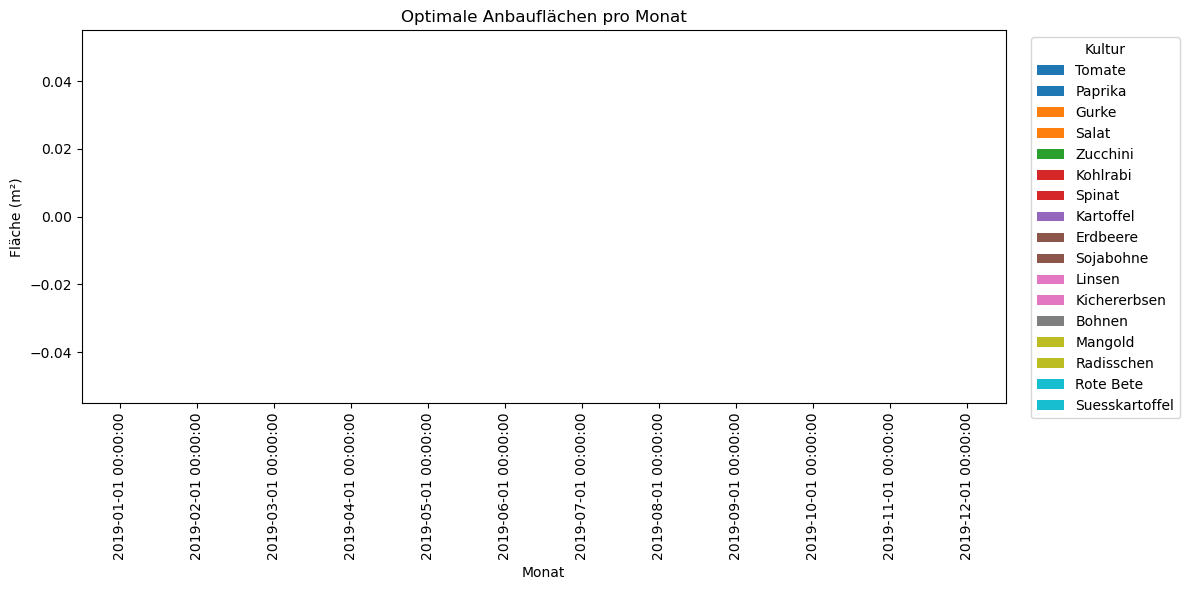

In [591]:
ax = df_area.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab10")
plt.title("Optimale Anbauflächen pro Monat")
plt.ylabel("Fläche (m²)")
plt.xlabel("Monat")

# Legende rechts außerhalb
plt.legend(title="Kultur", labels=crops, bbox_to_anchor=(1.02, 1), loc="upper left")

# Beschriftung in die Balken (Crop + Fläche)
for container, crop in zip(ax.containers, crops):
    labels = [f"{crop}\n{w:.0f}" if w > 0 else "" for w in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=7, color="black")

plt.tight_layout()
plt.show()


In [592]:
# =====================================================
#  Plots - Nährstoffe (Bedarf vs. verfügbar)
# =====================================================

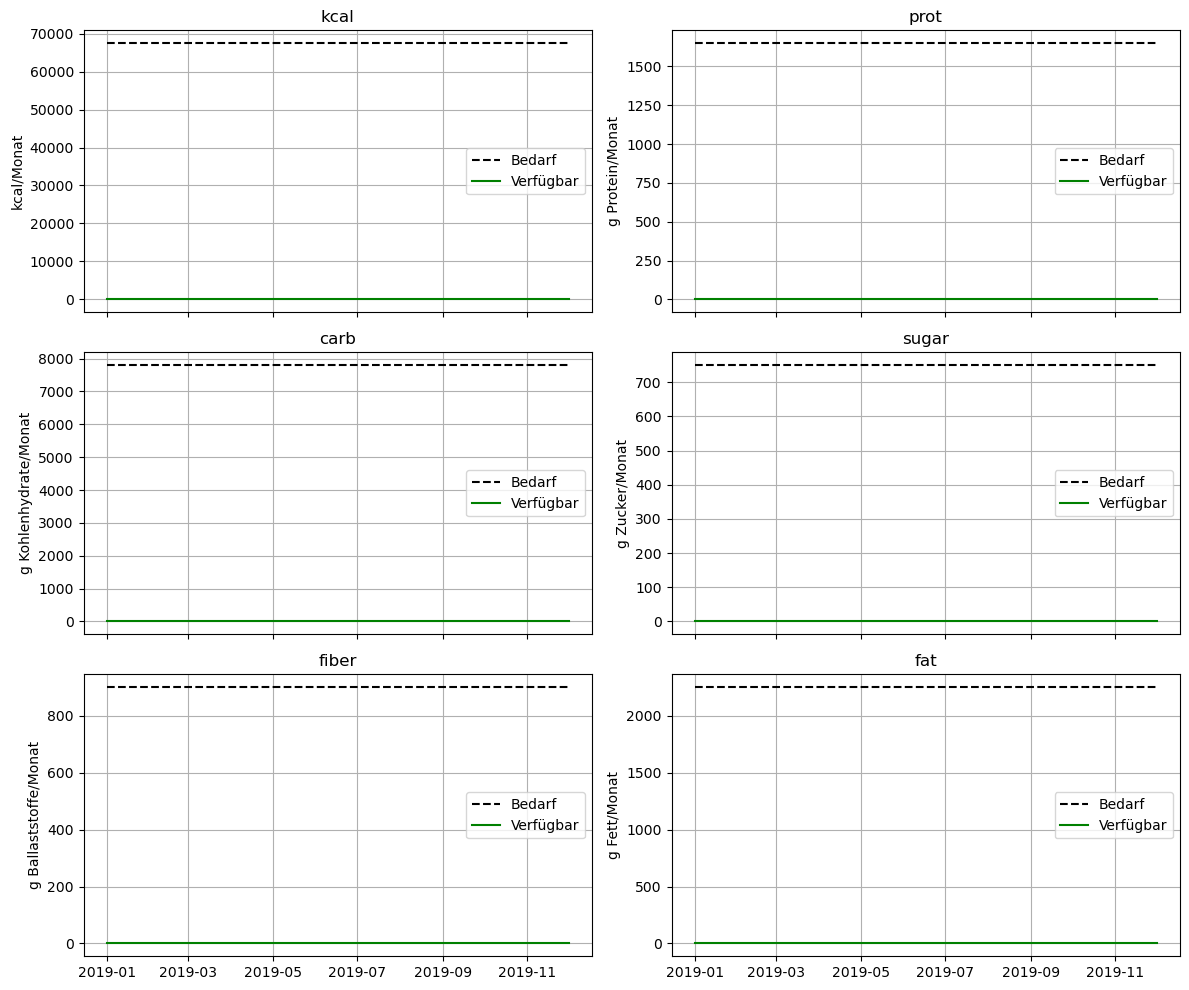

In [593]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axs = axs.ravel()

nutrients = [
    ("kcal",  demand_kcal,  "kcal/Monat"),
    ("prot",  demand_prot,  "g Protein/Monat"),
    ("carb",  demand_carb,  "g Kohlenhydrate/Monat"),
    ("sugar", demand_sugar, "g Zucker/Monat"),
    ("fiber", demand_fiber, "g Ballaststoffe/Monat"),
    ("fat",   demand_fat,   "g Fett/Monat"),
]

for ax, (key, demand_series, ylabel) in zip(axs, nutrients):
    ax.plot(demand_series.snapshot, demand_series, "k--", label="Bedarf")
    ax.plot(demand_series.snapshot, avail[key], "g-", label="Verfügbar")
    ax.set_title(key)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [594]:
# Lager: Alles-in-einem-Plot: kcal links, Prot/Carb/Fat rechts

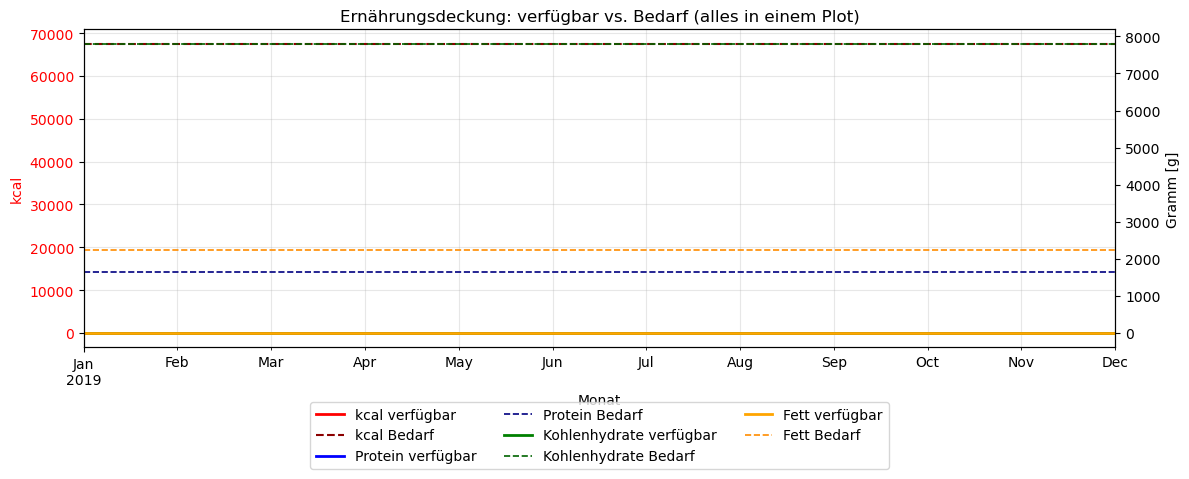

In [595]:
def monthly_available(stock_sol: xr.DataArray, prod_sol: xr.DataArray) -> xr.DataArray:
    stock_prev = stock_sol.shift(snapshot=1, fill_value=0)
    return (stock_prev + prod_sol).rename(stock_sol.name.replace("stock_", "avail_"))

# Verfügbar-Bilanzen aus den gelösten Variablen
stocks_opt = {k: m.variables[k].solution for k in
              ["stock_kcal","stock_prot","stock_carb","stock_sugar","stock_fiber","stock_fat"]}

avail_kcal = monthly_available(stocks_opt["stock_kcal"],  prod_kcal_sol)
avail_prot = monthly_available(stocks_opt["stock_prot"],  prod_prot_sol)
avail_carb = monthly_available(stocks_opt["stock_carb"],  prod_carb_sol)
avail_fat  = monthly_available(stocks_opt["stock_fat"],   prod_fat_sol)

# Ein Diagramm mit Zwillingsachse
fig, ax1 = plt.subplots(figsize=(12,5))

# Linke Y-Achse: kcal
avail_kcal.to_pandas().plot(ax=ax1, lw=2, color="red", label="kcal verfügbar")
demand_kcal.to_pandas().plot(ax=ax1, style="--", lw=1.5, color="darkred", label="kcal Bedarf")
ax1.set_ylabel("kcal", color="red")
ax1.tick_params(axis="y", labelcolor="red")

# Rechte Y-Achse: Makros in g
ax2 = ax1.twinx()

# Protein (blau)
avail_prot.to_pandas().plot(ax=ax2, lw=2, color="blue", label="Protein verfügbar")
demand_prot.to_pandas().plot(ax=ax2, style="--", lw=1.2, color="navy", label="Protein Bedarf")

# Kohlenhydrate (grün)
avail_carb.to_pandas().plot(ax=ax2, lw=2, color="green", label="Kohlenhydrate verfügbar")
demand_carb.to_pandas().plot(ax=ax2, style="--", lw=1.2, color="darkgreen", label="Kohlenhydrate Bedarf")

# Fett (orange)
avail_fat.to_pandas().plot(ax=ax2, lw=2, color="orange", label="Fett verfügbar")
demand_fat.to_pandas().plot(ax=ax2, style="--", lw=1.2, color="darkorange", label="Fett Bedarf")

ax2.set_ylabel("Gramm [g]")

# Titel, Gitter, Legende außen
ax1.set_title("Ernährungsdeckung: verfügbar vs. Bedarf (alles in einem Plot)")
ax1.set_xlabel("Monat")
ax1.grid(True, which="both", axis="both", alpha=0.3)

# Legende zusammenführen
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.tight_layout()
plt.show()


In [596]:
# Wasser und Lichtprofil definieren:

In [597]:
# Monatszuordnung/Hilfsfunktionen
snapshots_m = n.snapshots              # Monatsanfang (MS)
snapshots_h = pd.date_range("2019-01-01", periods=8760, freq="h")

# Kalendertage je Monat (korrekt, statt pauschal 30)
days_in_month = snapshots_m.to_series().dt.days_in_month
on_hours_month  = 16 * days_in_month

# Ergebnis aus der Optimierung (xarray, dims=["snapshot","crop"])
area_opt  = m.variables["area_active"].solution  # m²

# (1) Monatsfläche dieser Kultur als Pandas-Serie (Index = Monatsanfänge)
a_mon = area_opt.to_pandas()                  # m² @ Monatsinde

# (2) Auf Stunden-Index anheben: zwischen Monatsanfängen mit ffill konstant halten
a_h = a_mon.reindex(snapshots_h, method="ffill")              # m² @ Stundenindex

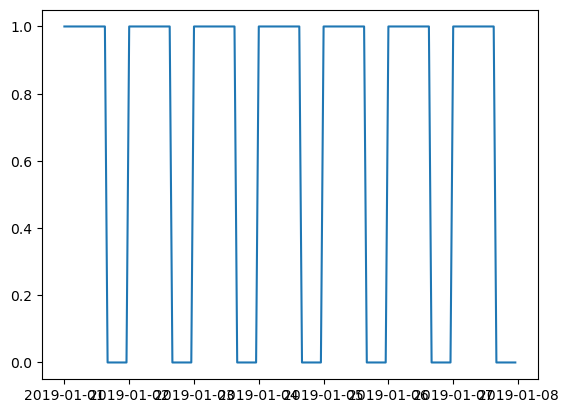

In [598]:
profiles_light = {}

def light_profile_16on_8off(snapshots_h):
    hours_of_day = np.arange(len(snapshots_h)) % 24  # 0,1,2,...,23,0,1,2,...
    on = (hours_of_day < 16).astype(float)  # 0..15 -> 1 (an), 16..23 -> 0 (aus)
    return pd.Series(on, index=snapshots_h, name="light_on")


light_on = light_profile_16on_8off(snapshots_h)

#(optional) Sichtprüfung: nur den ersten Tag plotten
first_day = light_on.loc["2019-01-01":"2019-01-07 23:00"]
plt.plot(first_day)
plt.show()

In [599]:
for crop in crops:
    # 1) Monats-Energie je m² aus Excel
    need_kwh_per_m2_month = float(df_crops_parameter.loc[crop, "light_kwh_per_m2_month"])

    # 2) kW/m² während 'an' -> pro Monat: (kWh/m²/Monat) / (ON-Stunden im Monat)
    P_on_mon = (need_kwh_per_m2_month / on_hours_month).rename("kW_per_m2_when_on")  # Index=MS

    # 3) auf Stunden heben und mit Schalter & Fläche multiplizieren
    P_on_h   = P_on_mon.reindex(snapshots_h, method="ffill")                          # kW/m² stündlich (nur Skalierung)
    prof_kW  = P_on_h * light_on * a_h[crop]                                          # kW = (kW/m²)*(-)*m²

    profiles_light[crop] = prof_kW

In [600]:
profiles_water = {}


def water_profile(T_days, W_max, index_h, start_hour=0):
    """
    Parabolisches Profil über T_days.
    W_max: L/(m²·Tag); Rückgabe: L/(m²·h) auf Stundenindex.
    """
    T_h = int(round(float(T_days) * 24))
    if T_h <= 0 or W_max < 0:
        return pd.Series(0.0, index=index_h)

    hours = np.arange(len(index_h))
    tau = (hours - int(start_hour)) % T_h
    t_d = tau / 24.0

    core = 1.0 - ((t_d - T_days / 2) / (T_days / 2)) ** 2  # 0 an Rand, 1 in Mitte
    core = np.clip(core, 0.0, None)

    return pd.Series((W_max * core) / 24.0, index=index_h)  # L/(m²·h)

In [601]:
for crop in crops:
    p = df_crops_parameter.loc[crop]
    w_unit_Lpm2h = water_profile(T_days=p["T_days"],
                                 W_max=p["W_max"],
                                 index_h=snapshots_h,
                                 start_hour=0)              # L/(m²·h)
    profiles_water[crop] = w_unit_Lpm2h * a_h[crop]        # L/h


In [602]:
total_light_kWh  = pd.DataFrame(profiles_light).sum(axis=1)   # kW gesamt
total_water_Lph = pd.DataFrame(profiles_water).sum(axis=1)   # L/h gesamt

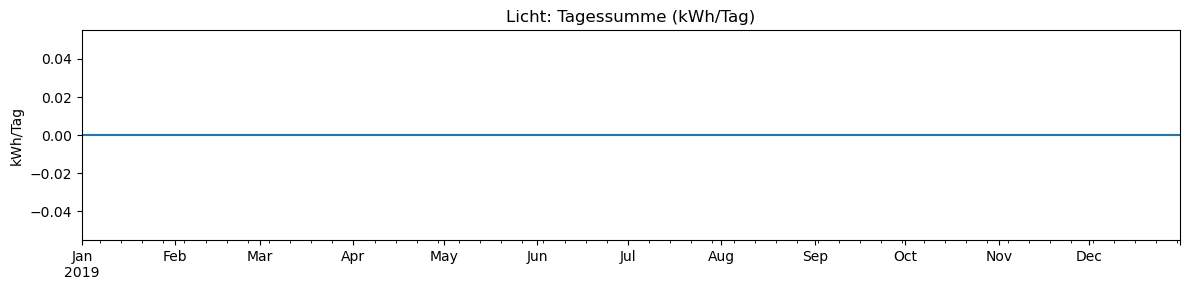

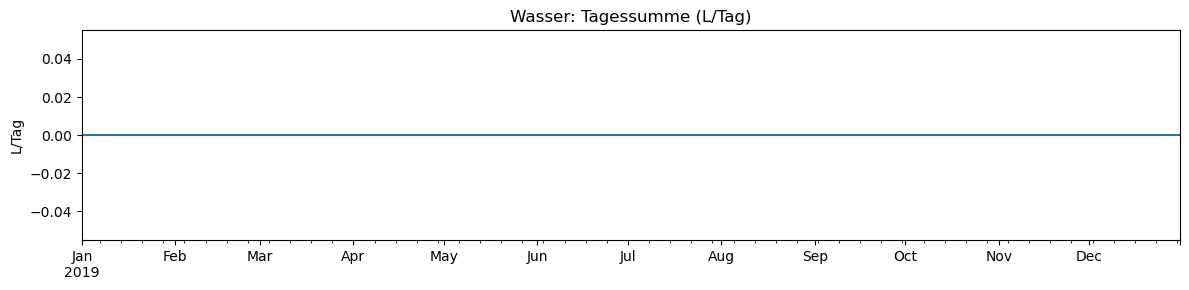

In [603]:
# Tages- und Monatssummen
total_light_kWh_day  = total_light_kWh.resample("D").sum()       # kWh/Tag
total_water_L_day    = total_water_Lph.resample("D").sum()      # Liter/Tag

total_light_kWh_mon  = total_light_kWh.resample("MS").sum()      # kWh/Monat
total_water_L_mon    = total_water_Lph.resample("MS").sum()     # Liter/Monat

# Schneller Check-Plot (optional)
ax = total_light_kWh_day.plot(figsize=(12,3), title="Licht: Tagessumme (kWh/Tag)")
ax.set_ylabel("kWh/Tag"); plt.tight_layout(); plt.show()

ax = total_water_L_day.plot(figsize=(12,3), title="Wasser: Tagessumme (L/Tag)")
ax.set_ylabel("L/Tag"); plt.tight_layout(); plt.show()


CSV exportiert: load_profiles_hourly_final.csv


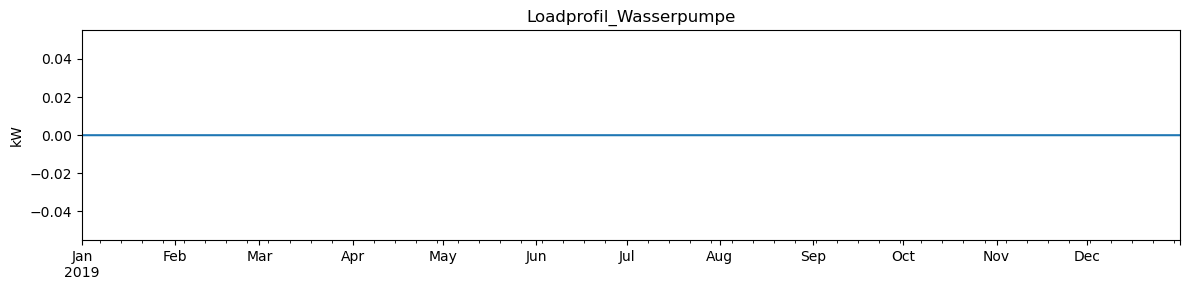

In [604]:
# Wasserprofil anpassen auf W/h
# Aus dem Datenblatt (h=3m, n = 15%)
Faktor_water_to_W = 0.0545
Faktor_water_to_kW_per_h = Faktor_water_to_W / 1000

# Wasserlastprofil umstellen
total_water_kW_per_h = total_water_Lph * Faktor_water_to_kW_per_h

load_profiles = pd.DataFrame({
    "light_kW": total_light_kWh,
    "water_L_per_h": total_water_Lph,
    "water_kW": total_water_kW_per_h
})

# Als CSV speichern:
# load_profiles.to_csv("../Input/load_profiles_hourly_final.csv", index_label="timestamp")

print("CSV exportiert: load_profiles_hourly_final.csv")
ax = total_water_kW_per_h.plot(figsize=(12, 3), title="Loadprofil_Wasserpumpe")
ax.set_ylabel("kW")
plt.tight_layout()
plt.show()

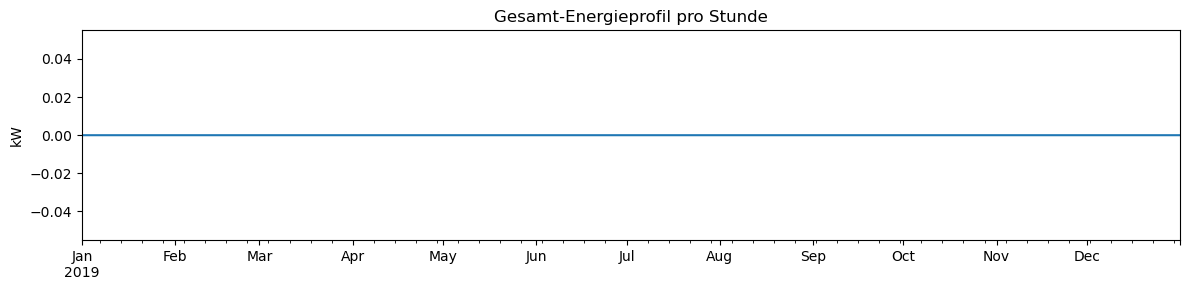

In [605]:
# Gesamtenergie loadprofile

total_energy_kWh = total_light_kWh + total_water_kW_per_h
total_energy_kWh_day  = total_energy_kWh.resample("D").sum()

# Plot

ax = total_energy_kWh.plot(figsize=(12,3), title="Gesamt-Energieprofil pro Stunde")
ax.set_ylabel("kW")
plt.tight_layout()
plt.show()

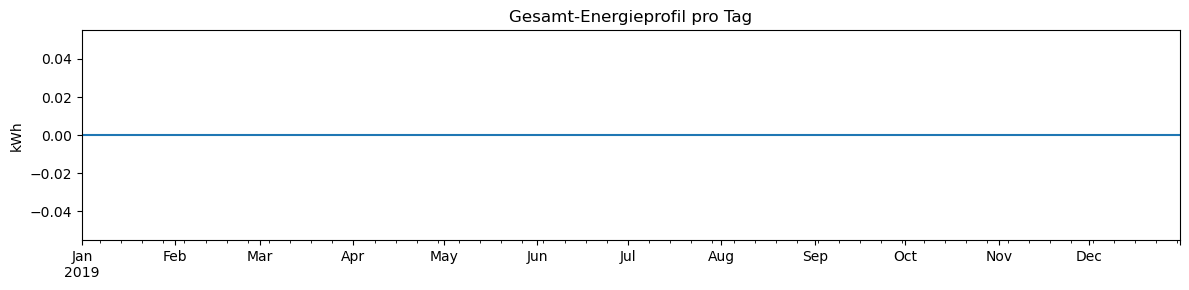

In [606]:
ax = total_energy_kWh_day.plot(figsize=(12,3), title="Gesamt-Energieprofil pro Tag")
ax.set_ylabel("kWh")
plt.tight_layout()
plt.show()


0.0


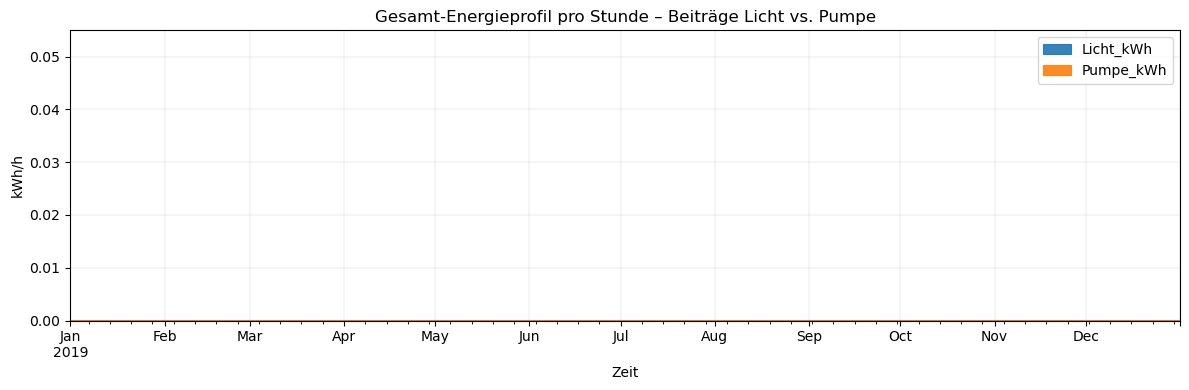

In [607]:
total_energy_year_kwh = total_energy_kWh.sum()

print(total_energy_year_kwh)
# Gesamtprofil (kWh pro Stunde):
total_energy_kWh = total_light_kWh + total_water_kW_per_h

# =========================
# 2) Gestapelte Flächendarstellung (stündlich)
# =========================
df_hour = pd.DataFrame({
    "Licht_kWh": total_light_kWh,
    "Pumpe_kWh": total_water_kW_per_h
})

ax = df_hour.plot.area(figsize=(12, 4), linewidth=0.8, alpha=0.9,
                       title="Gesamt-Energieprofil pro Stunde – Beiträge Licht vs. Pumpe")
ax.set_ylabel("kWh/h")
ax.set_xlabel("Zeit")
ax.grid(True, linewidth=0.3, alpha=0.6)
plt.tight_layout()
plt.show()

In [608]:
# Gestapelte Balken (tägliche Summen)

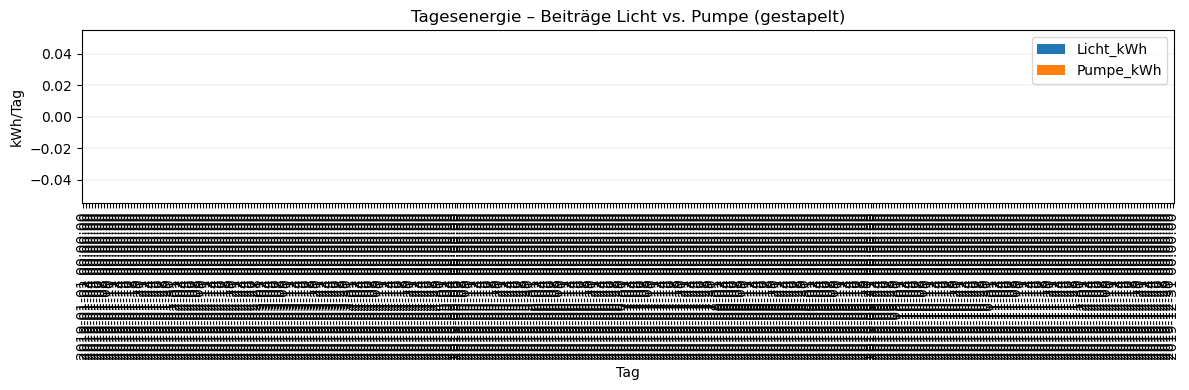

Jahresenergie Licht: 0.00 kWh
Jahresenergie Pumpe: 0.00 kWh
Jahresenergie gesamt: 0.00 kWh


In [609]:
df_day = df_hour.resample("D").sum()

ax = df_day.plot(kind="bar", stacked=True, figsize=(12,4),
                 title="Tagesenergie – Beiträge Licht vs. Pumpe (gestapelt)")
ax.set_ylabel("kWh/Tag")
ax.set_xlabel("Tag")
ax.grid(True, axis="y", linewidth=0.3, alpha=0.6)
plt.tight_layout()
plt.show()

# =========================
# 4) Kontrolle: Jahressummen
# =========================
jahr_sum_licht = df_hour["Licht_kWh"].sum()
jahr_sum_pumpe = df_hour["Pumpe_kWh"].sum()
jahr_sum_total = total_energy_kWh.sum()
print(f"Jahresenergie Licht: {jahr_sum_licht:.2f} kWh")
print(f"Jahresenergie Pumpe: {jahr_sum_pumpe:.2f} kWh")
print(f"Jahresenergie gesamt: {jahr_sum_total:.2f} kWh")
